### Workflow demo

In this interactive notebook, a full worked example of the code is provided, as well as demonstrations of some of the substructures the atropisomers workflow can be applied to. Outputs from the relevant softwares (xTB, CREST, CENSO, Gaussian) for the worked example are included in `/example`. Note that the code to run QM software is not provided; instead, we recommend that users apply their own conformational searching and QM optimization procedures, depending on their preferred software and programs. In this way, users can set the level of theory, solvent model, temperature, conformational search parameters, and other relevant workflow settings themselves.

#### Imports

In [1]:
# General imports
import subprocess
from pathlib import Path

# Import the atropisomers class
from atropisomers import AtropRun

#### Worked example

In this section, we provide a full worked example of the atropisomers workflow applied to an arbitrary compound. Outputs from the relevant softwares related to this example are included in `/example`.

Screen the structure for atropisomeric axes:

Biaryl (6-6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 8-9 with atoms [8, 7, 1] and [9, 11, 16]

Summary of dihedrals for GIC scans:
 - scan 1: {'8_9': [[7, 8, 9, 11], [1, 8, 9, 16]]}
 - scan 2: {'8_9': [[7, 8, 9, 16], [1, 8, 9, 11]]}

Summary of identified substructures:
 - {'8_9': 'Biaryl (6-6)'}

Rotatable bond:


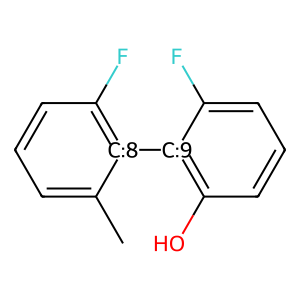

GIC atoms:


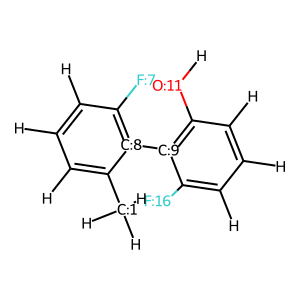

In [2]:
# Define SMILES string to screen
SMILES = "Cc1cccc(F)c1-c1c(O)cccc1F"

# Initialize the workflow
atrop = AtropRun(SMILES)

# Parse the structure
ts_indexes = atrop.cheminformatics(filter=True)

The cheminformatics function returns indexes corresponding to any identified TS bonds. In this case, only one is returned. This is the index we will screen in this example.

In [3]:
ts_index = list(ts_indexes)[0]
print(f"TS index to screen: {ts_index}")

TS index to screen: 8_9


Conformationally search the input structure (GS) and optimize the ensemble. We do not provide the code for this procedure, but example files are provided in the following directories:

In [4]:
embedding_dir = Path("example/gs/confs") # 20 conformers embedded with RDKit
xtb_dir = Path("example/gs/xtb") # xTB calculations for 20 conformers
crest_dir = Path("example/gs/crest") # CREST search for lowest xTB conformer
censo_dir = Path("example/gs/censo") # CREST refinment of ensemble
gaussian_dir = Path("example/gs/gaussian") # Gaussian optimizations of lowest energy conformer


From the above optimization procedure, define the lowest energy conformer. In this case, we define the lowest energy conformer from CREST and CENSO:

In [5]:
gs_censo = Path("example/gs/censo/most_stable_part2.xyz") # Lowest energy conformer from CENSO
gs_gaussian = Path("example/gs/gaussian/g_opt_react.log") # Lowest energy conformer from Gaussian

Set-up rotational GIC scans in both directions. We use the lowest energy CENSO geometry to set up the scan so we don't have to wait for the Gaussian calculation.

In [6]:
# Define scan template
scan_template = """
%mem={memory}
%nprocshared={cpu}
# opt=(addgic,loose) {route_card}

example

{charge} {multiplicity}
{coordinates}
bond1=D({dihedral1})
bond2=D({dihedral2})
coord=[bond1+bond2]
coord(nsteps=30,stepsize=0.2)

"""

In [7]:
# Define level of theory
route_card = "bp86 def2svp empiricaldispersion=GD3BJ" # Gas-phase

# Read XYZ from CENSO output
with open(gs_censo) as f:
    gs_xyz = f.readlines()[2:] # Skip first two lines of XYZ file

# Populate template for forward scan
scan_1 = scan_template.format(
    memory="12000MB", cpu=4,
    route_card=route_card,
    charge=atrop.charge,
    multiplicity=1,
    coordinates="".join(gs_xyz),
    dihedral1=",".join(map(str, atrop.all_gic_1['8_9'][0])),
    dihedral2=",".join(map(str, atrop.all_gic_1['8_9'][1])),
    )

# Populate template for backward scan
scan_2 = scan_template.format(
    memory="12000MB", cpu=4,
    route_card=route_card,
    charge=atrop.charge,
    multiplicity=1,
    coordinates="".join(gs_xyz),
    dihedral1=",".join(map(str, atrop.all_gic_2['8_9'][0])),
    dihedral2=",".join(map(str, atrop.all_gic_2['8_9'][1])),
    )

# The scans are saved to the following files
scan_1_inp = Path("example/ts_8_9/scans/scan_1.gjf")
scan_2_inp = Path("example/ts_8_9/scans/scan_2.gjf")

# Save the scan inputs
with open(scan_1_inp, "w") as f:
    f.write(scan_1)
with open(scan_2_inp, "w") as f:
    f.write(scan_2)

Run the scans:

In [8]:
# Outputs:
scan_1_out = Path("example/ts_8_9/scans/scan_1.log")
scan_2_out = Path("example/ts_8_9/scans/scan_2.log")

Analyze the completed scans:

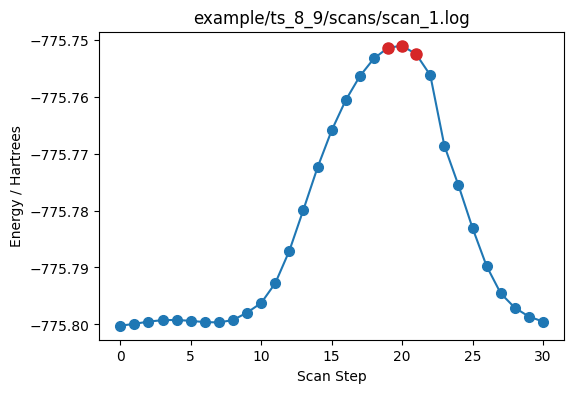

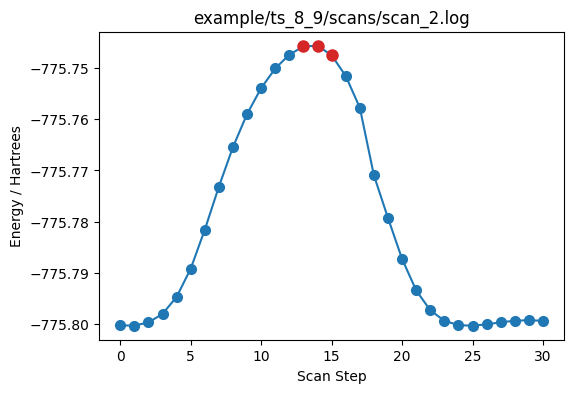

Lowest energy maximum found in scan: example/ts_8_9/scans/scan_1.log


In [9]:
# Get coordinates for three candidate TSs
max_xyz, minus1_xyz, plus1_xyz = atrop.scan_analysis(
    {scan_1_out: atrop.all_gic_1[ts_index], scan_2_out: atrop.all_gic_2[ts_index]} # Provide the appropriate GIC dihedrals for each scan
) 

Optimize the TS candidates from the coordinates in `max_xyz`, `minus1_xyz` and `plus1_xyz`. We do not provide the code for this procedure, but example files are provided in the following directories:

In [10]:
# 1. Optimize TS candidates with constraints on the dihedrals in either m.all_gic_1['8_9'] or m.all_gic_2['8_9']
ts_candidate_1_frozen_inp = Path("example/ts_8_9/candidates/opt_frozen/max/g_opt_frozen.gjf") # Generated from coordinates in max_xyz
ts_candidate_2_frozen_inp = Path("example/ts_8_9/candidates/opt_frozen/minus1/g_opt_frozen.gjf") # Generated from coordinates in minus1_xyz
ts_candidate_3_frozen_inp = Path("example/ts_8_9/candidates/opt_frozen/plus1/g_opt_frozen.gjf") # Generated from coordinates in plus1_xyz

# Outputs:
ts_candidate_1_frozen_out = Path("example/ts_8_9/candidates/opt_frozen/max/g_opt_frozen.log")
ts_candidate_2_frozen_out = Path("example/ts_8_9/candidates/opt_frozen/minus1/g_opt_frozen.log")
ts_candidate_3_frozen_out = Path("example/ts_8_9/candidates/opt_frozen/plus1/g_opt_frozen.log")

In [11]:
# 2. Optimize the TS candidates without constraints
ts_candidate_1_inp = Path("example/ts_8_9/candidates/opt_ts/max/g_opt_ts.gjf")
ts_candidate_2_inp = Path("example/ts_8_9/candidates/opt_ts/minus1/g_opt_ts.gjf")
ts_candidate_3_inp = Path("example/ts_8_9/candidates/opt_ts/plus1/g_opt_ts.gjf")

# Outputs:
ts_candidate_1_out = Path("example/ts_8_9/candidates/opt_ts/max/g_opt_ts.log")
ts_candidate_2_out = Path("example/ts_8_9/candidates/opt_ts/minus1/g_opt_ts.log")
ts_candidate_3_out = Path("example/ts_8_9/candidates/opt_ts/plus1/g_opt_ts.log")

Analyze optimized TS candidates (check they are valid and get their energies and geometries):

In [12]:
ts_candidate_xyzs, ts_candidate_energies = atrop.ts_analysis(
    [ts_candidate_1_out, ts_candidate_2_out, ts_candidate_3_out], # TS candidates
    ts_index, # Provide the TS index
)

Log file: example/ts_8_9/candidates/opt_ts/max/g_opt_ts.log
Displacement %: 67.73
Dihedral changes: 1.17°, 2.10°, 1.17°, 2.10°
TS validation passed.

Log file: example/ts_8_9/candidates/opt_ts/minus1/g_opt_ts.log
Displacement %: 67.73
Dihedral changes: 3.22°, 4.99°, 3.22°, 4.99°
TS validation passed.

Log file: example/ts_8_9/candidates/opt_ts/plus1/g_opt_ts.log
Displacement %: 67.73
Dihedral changes: 4.26°, 10.46°, 4.26°, 10.46°
TS validation passed.



Conformationally search the lowest energy TS candidate and optimize the ensemble. We do not provide the code for this procedure, but example files are provided in the following directories:

In [13]:
# Find lowest energy candidate TS from ts_candidate_energies
lowest_ts_log = Path(min(ts_candidate_energies, key=ts_candidate_energies.get))
lowest_ts_xyz = ts_candidate_xyzs[lowest_ts_log] # Input coordinates for conformational search

In [14]:
crest_ts_dir = Path("example/ts_8_9/conformers/crest") # CREST search with constraints on the dihedrals in either m.all_gic_1['8_9'] or m.all_gic_2['8_9']
spe_ts_dir = Path("example/ts_8_9/conformers/spe") # Low-level DFT single-point energies of TS conformers
opt_frozen_ts_dir = Path("example/ts_8_9/conformers/opt_frozen") # Optimized TS conformers with constraints (same as above)
opt_ts_dir = Path("example/ts_8_9/conformers/opt_ts") # Optimized TS conformers

Analyze optimized TS conformers (check they are valid and get their energies and geometries):

In [15]:
# Get all optimized TS conformers
ts_conformer_logs = list(opt_ts_dir.glob("**/g_opt_ts_confs.log"))

In [16]:
ts_conformer_xyzs, ts_conformer_energies = atrop.ts_analysis(
    ts_conformer_logs, # TS conformer
    ts_index, # Provide the TS index
)

Log file: example/ts_8_9/conformers/opt_ts/2/g_opt_ts_confs.log
Displacement %: 62.72
Dihedral changes: 0.88°, 9.04°, 0.88°, 9.04°
TS validation passed.

Log file: example/ts_8_9/conformers/opt_ts/1/g_opt_ts_confs.log
Displacement %: 67.73
Dihedral changes: 0.09°, 0.73°, 0.09°, 0.73°
TS validation passed.



Identify the lowest-energy TS conformer from both the scan candidates and the conformational search:

In [17]:
# Combine results from scans and conformational searches
ts_all_energies = ts_candidate_energies | ts_conformer_energies
ts_all_xyzs = ts_candidate_xyzs | ts_conformer_xyzs

In [18]:
# Find lowest energy TS conformer
lowest_ts_log = Path(min(ts_all_energies, key=ts_all_energies.get))
lowest_ts_xyz = ts_all_xyzs[lowest_ts_log]

In [19]:
print(f"Lowest energy GS conformer: {gs_gaussian}")
print(f"Lowest energy TS conformer: {lowest_ts_log}")

Lowest energy GS conformer: example/gs/gaussian/g_opt_react.log
Lowest energy TS conformer: example/ts_8_9/candidates/opt_ts/max/g_opt_ts.log


Calculate high-level single point energies on the lowest energy GS and TS. We do not provide the code for this procedure, but example files are defined below:

In [20]:
gs_spe_inp = gs_gaussian.parent / gs_gaussian.stem / "_spe.gjf"
ts_spe_inp = lowest_ts_log.parent / lowest_ts_log.stem / "_spe.gjf"

# Outputs:
gs_spe_out = gs_gaussian.parent / gs_gaussian.stem / "_spe.log"
ts_spe_out = lowest_ts_log.parent / lowest_ts_log.stem / "_spe.log"

Extract free energies (at 298.15K) and calculate barrier:

In [21]:
# Extract GS free energies with goodvibes
gs_gv = gs_gaussian.parent/'Goodvibes_output.dat'
subprocess.run(f"python -m goodvibes --qs grimme -v 1.0 -t 298.15 {gs_gaussian} --spc spe > {gs_gv}", shell=True)
gs_free_energy = atrop.extract_free_energy(gs_gv)

# Extract TS free energies with goodvibes
ts_gv = lowest_ts_log.parent/'Goodvibes_output.dat'
subprocess.run(f"python -m goodvibes --qs grimme -v 1.0 -t 298.15 {lowest_ts_log} --spc spe > {ts_gv}", shell=True)
ts_free_energy = atrop.extract_free_energy(ts_gv)

In [22]:
# Calculate the barrier and convert to kcal/mol
barrier = round((ts_free_energy - gs_free_energy)*627.5095,2)
print(barrier)

35.97


In [23]:
# Correct the barrier with the overall regression (optional)
corrected_barrier = round(atrop.correct_barrier(barrier, ts_index, overall=True),2)
print(corrected_barrier)

36.73


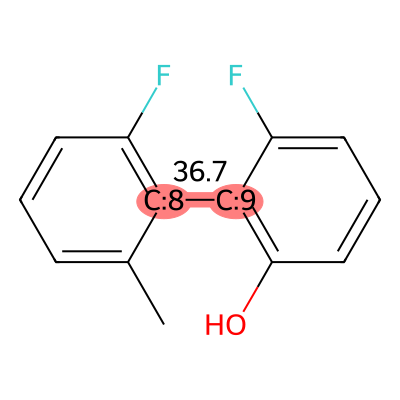

In [24]:
# Visualize the barrier
atrop.visualize_barrier(ts_index, round(corrected_barrier,1))

#### Substructure examples

In this section, we demonstrate some of the substructures the atropisomers workflow can be applied:

In [25]:
def parse(smiles):
    """Helper function to run atropisomer detection."""
    print(f"### SMILES: {smiles}\n")
    m = AtropRun(smiles)
    m.cheminformatics(filter=True)

### SMILES: Cc1cccc(C)c1c2c(C)cccc2Cl

Biaryl (6-6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 8-9 with atoms [8, 7, 1] and [9, 11, 16]

Summary of dihedrals for GIC scans:
 - scan 1: {'8_9': [[7, 8, 9, 11], [1, 8, 9, 16]]}
 - scan 2: {'8_9': [[7, 8, 9, 16], [1, 8, 9, 11]]}

Summary of identified substructures:
 - {'8_9': 'Biaryl (6-6)'}

Rotatable bond:


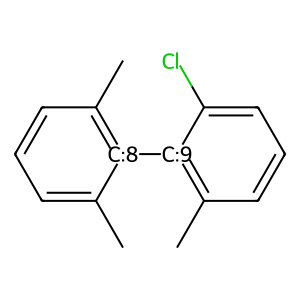

GIC atoms:


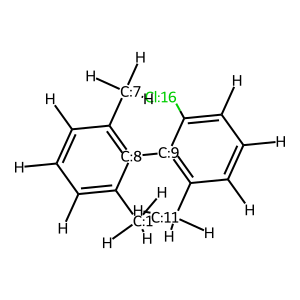

### SMILES: Cc1occ(C)c1c2c(C)cccc2C

Biaryl (6-5) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 7-8 with atoms [7, 6, 1] and [8, 10, 15]

Summary of dihedrals for GIC scans:
 - scan 1: {'7_8': [[6, 7, 8, 10], [1, 7, 8, 15]]}
 - scan 2: {'7_8': [[6, 7, 8, 15], [1, 7, 8, 10]]}

Summary of identified substructures:
 - {'7_8': 'Biaryl (6-5)'}

Rotatable bond:


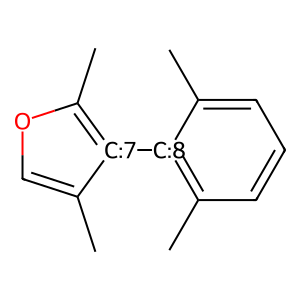

GIC atoms:


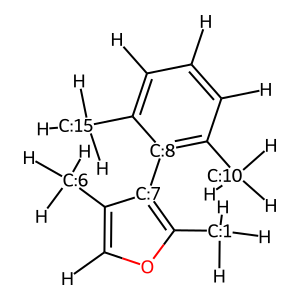

### SMILES: Cc1occ(C)c1c2cocc2C

Biaryl (5-5) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 7-8 with atoms [7, 6, 1] and [8, 21, 13]

Summary of dihedrals for GIC scans:
 - scan 1: {'7_8': [[6, 7, 8, 21], [1, 7, 8, 13]]}
 - scan 2: {'7_8': [[6, 7, 8, 13], [1, 7, 8, 21]]}

Summary of identified substructures:
 - {'7_8': 'Biaryl (5-5)'}

Rotatable bond:


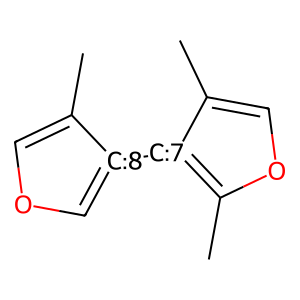

GIC atoms:


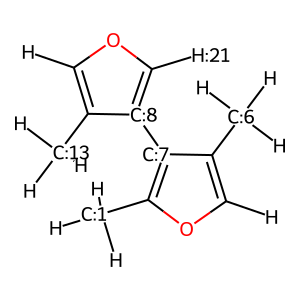

### SMILES: CCOC(=O)c1c(C)[nH]c(c2ccccc2)c1c3c([nH]c(C)c3C(=O)OCC)c4ccccc4

Biaryl (6-5) match identified:
 - too many hydrogens and/or lone pairs (>2): skipping the calculation
Biaryl (6-5) match identified:
 - too many hydrogens and/or lone pairs (>2): skipping the calculation
Biaryl (5-5) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 17-18 with atoms [17, 11, 4] and [18, 29, 24]

Summary of dihedrals for GIC scans:
 - scan 1: {'17_18': [[11, 17, 18, 29], [4, 17, 18, 24]]}
 - scan 2: {'17_18': [[11, 17, 18, 24], [4, 17, 18, 29]]}

Summary of identified substructures:
 - {'17_18': 'Biaryl (5-5)'}

Rotatable bond:


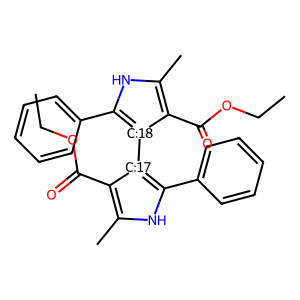

GIC atoms:


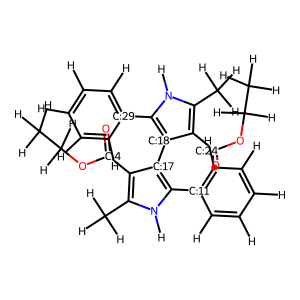

### SMILES: CC(=O)N[C@H]1CCC2=CC(=C(C(=C2C3=CC=C(C(=O)C=C13)OC)OC)OC)OC

Biaryl (7-6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 13-14 with atoms [13, 24, 7] and [14, 40, 5]
Amide match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 4-2 with atoms [4, 5, 33] and [2, 1, 3]

Summary of dihedrals for GIC scans:
 - scan 1: {'13_14': [[24, 13, 14, 40], [7, 13, 14, 5]], '2_4': [[5, 4, 2, 1], [33, 4, 2, 3]]}
 - scan 2: {'13_14': [[24, 13, 14, 5], [7, 13, 14, 40]], '2_4': [[5, 4, 2, 3], [33, 4, 2, 1]]}

Summary of identified substructures:
 - {'13_14': 'Biaryl (7-6)', '2_4': 'Amide'}

Rotatable bond:


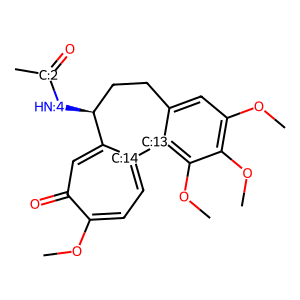

GIC atoms:


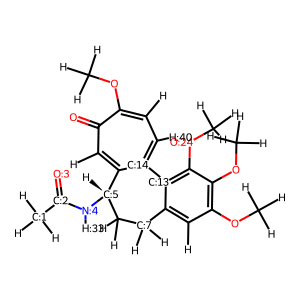

### SMILES: NC(=O)c1cccc2CCCC(=O)c12

Benzamide (6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 4-2 with atoms [4, 17, 12] and [2, 1, 3]
Amide match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 1-2 with atoms [1, 15, 16] and [2, 3, 4]

Summary of dihedrals for GIC scans:
 - scan 1: {'2_4': [[17, 4, 2, 1], [12, 4, 2, 3]], '1_2': [[15, 1, 2, 3], [16, 1, 2, 4]]}
 - scan 2: {'2_4': [[17, 4, 2, 3], [12, 4, 2, 1]], '1_2': [[15, 1, 2, 4], [16, 1, 2, 3]]}

Summary of identified substructures:
 - {'2_4': 'Benzamide (6)', '1_2': 'Amide'}

Rotatable bond:


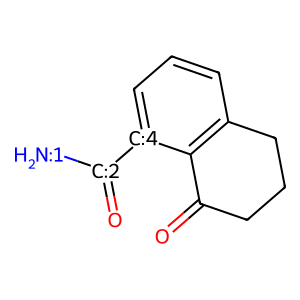

GIC atoms:


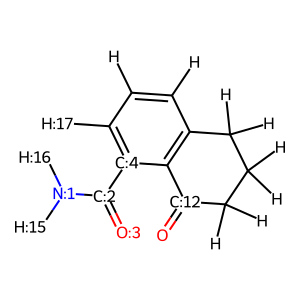

### SMILES: NC(=S)c1cccc2CCCC(=O)c12

Thiobenzamide (6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 4-2 with atoms [4, 17, 12] and [2, 1, 3]
Thioamide match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 1-2 with atoms [1, 15, 16] and [2, 3, 4]

Summary of dihedrals for GIC scans:
 - scan 1: {'2_4': [[17, 4, 2, 1], [12, 4, 2, 3]], '1_2': [[15, 1, 2, 3], [16, 1, 2, 4]]}
 - scan 2: {'2_4': [[17, 4, 2, 3], [12, 4, 2, 1]], '1_2': [[15, 1, 2, 4], [16, 1, 2, 3]]}

Summary of identified substructures:
 - {'2_4': 'Thiobenzamide (6)', '1_2': 'Thioamide'}

Rotatable bond:


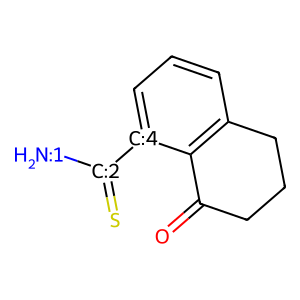

GIC atoms:


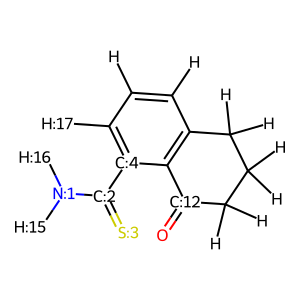

### SMILES: CC(=O)Nc1cccc2CCCC(=O)c12

Reverse benzamide (6) match identified:
 - too many hydrogens and/or lone pairs (>1): skipping the calculation
Amide match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 4-2 with atoms [4, 5, 19] and [2, 1, 3]

Summary of dihedrals for GIC scans:
 - scan 1: {'2_4': [[5, 4, 2, 1], [19, 4, 2, 3]]}
 - scan 2: {'2_4': [[5, 4, 2, 3], [19, 4, 2, 1]]}

Summary of identified substructures:
 - {'2_4': 'Amide'}

Rotatable bond:


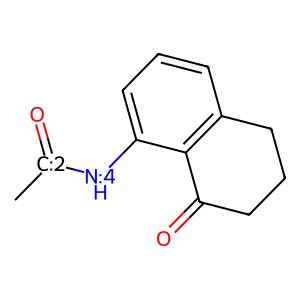

GIC atoms:


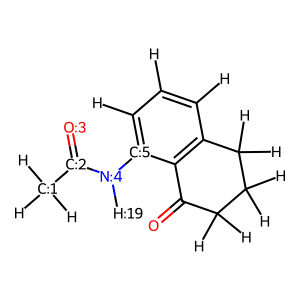

### SMILES: CC1CCCC(=O)N1c2c(C)cccc2C

Aryl-aliphatic (6-6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 8-9 with atoms [8, 7, 2] and [9, 11, 16]
Reverse benzamide (6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 9-8 with atoms [9, 11, 16] and [8, 6, 2]
Amide match identified:
 - invalid pattern for atropisomerism (amide in ring): skipping the calculation

Summary of dihedrals for GIC scans:
 - scan 1: {'8_9': [[11, 9, 8, 6], [16, 9, 8, 2]]}
 - scan 2: {'8_9': [[11, 9, 8, 2], [16, 9, 8, 6]]}

Summary of identified substructures:
 - {'8_9': 'Reverse benzamide (6)'}

Rotatable bond:


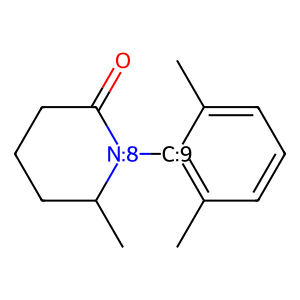

GIC atoms:


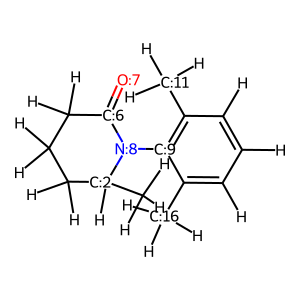

### SMILES: Cc1ccoc1C(=O)N

Benzamide (5) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 6-7 with atoms [6, 5, 1] and [7, 8, 9]
Amide match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 9-7 with atoms [9, 15, 16] and [7, 6, 8]

Summary of dihedrals for GIC scans:
 - scan 1: {'6_7': [[5, 6, 7, 8], [1, 6, 7, 9]], '7_9': [[15, 9, 7, 6], [16, 9, 7, 8]]}
 - scan 2: {'6_7': [[5, 6, 7, 9], [1, 6, 7, 8]], '7_9': [[15, 9, 7, 8], [16, 9, 7, 6]]}

Summary of identified substructures:
 - {'6_7': 'Benzamide (5)', '7_9': 'Amide'}

Rotatable bond:


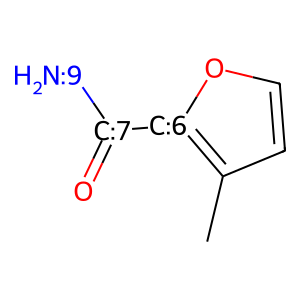

GIC atoms:


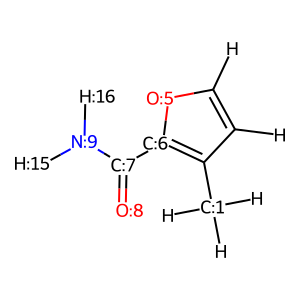

### SMILES: CC(=O)N

Amide match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 4-2 with atoms [4, 8, 9] and [2, 1, 3]

Summary of dihedrals for GIC scans:
 - scan 1: {'2_4': [[8, 4, 2, 1], [9, 4, 2, 3]]}
 - scan 2: {'2_4': [[8, 4, 2, 3], [9, 4, 2, 1]]}

Summary of identified substructures:
 - {'2_4': 'Amide'}

Rotatable bond:


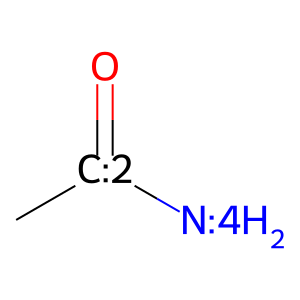

GIC atoms:


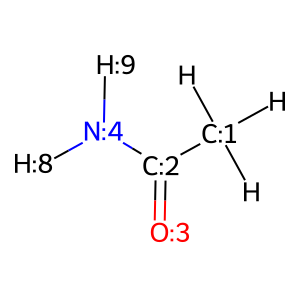

### SMILES: CN(C)C(C)=S

Thioamide match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 2-4 with atoms [2, 1, 3] and [4, 5, 6]

Summary of dihedrals for GIC scans:
 - scan 1: {'2_4': [[1, 2, 4, 5], [3, 2, 4, 6]]}
 - scan 2: {'2_4': [[1, 2, 4, 6], [3, 2, 4, 5]]}

Summary of identified substructures:
 - {'2_4': 'Thioamide'}

Rotatable bond:


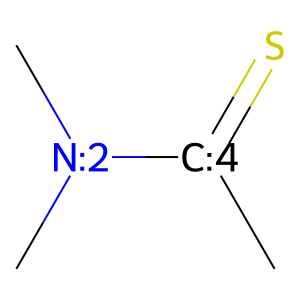

GIC atoms:


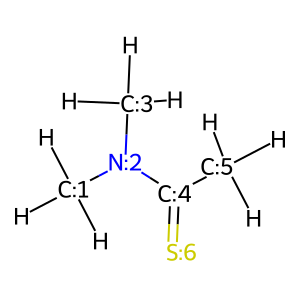

### SMILES: CS(=O)c1c(C)ccc2CCCC(=O)c12

Sulfoxide (6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 4-2 with atoms [4, 6, 13] and [2, 1, 3]

Summary of dihedrals for GIC scans:
 - scan 1: {'2_4': [[6, 4, 2, 1], [13, 4, 2, 3]]}
 - scan 2: {'2_4': [[6, 4, 2, 3], [13, 4, 2, 1]]}

Summary of identified substructures:
 - {'2_4': 'Sulfoxide (6)'}

Rotatable bond:


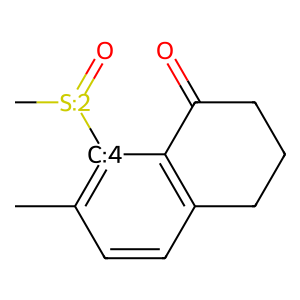

GIC atoms:


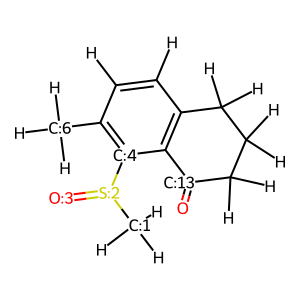

### SMILES: CS(=O)c1c(C)oc2CCCC(=O)c12

Sulfoxide (5) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 4-2 with atoms [4, 6, 12] and [2, 1, 3]

Summary of dihedrals for GIC scans:
 - scan 1: {'2_4': [[6, 4, 2, 1], [12, 4, 2, 3]]}
 - scan 2: {'2_4': [[6, 4, 2, 3], [12, 4, 2, 1]]}

Summary of identified substructures:
 - {'2_4': 'Sulfoxide (5)'}

Rotatable bond:


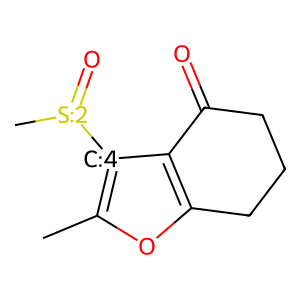

GIC atoms:


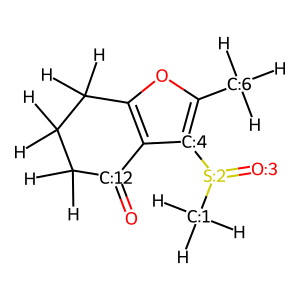

### SMILES: CS(=O)(=O)c1c(C)ccc2CCCC(=O)c12

Sulfoxide (6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 5-2 with atoms [5, 7, 14] and [2, 1, 4]
Sulfoxide (6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 5-2 with atoms [5, 7, 14] and [2, 1, 4]
Sulfone (6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 5-2 with atoms [5, 7, 14] and [2, 1, 4]

Summary of dihedrals for GIC scans:
 - scan 1: {'2_5': [[7, 5, 2, 1], [14, 5, 2, 4]]}
 - scan 2: {'2_5': [[7, 5, 2, 4], [14, 5, 2, 1]]}

Summary of identified substructures:
 - {'2_5': 'Sulfone (6)'}

Rotatable bond:


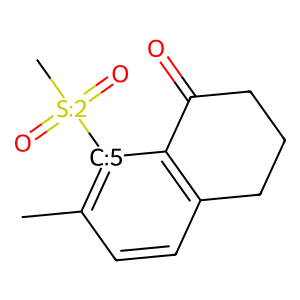

GIC atoms:


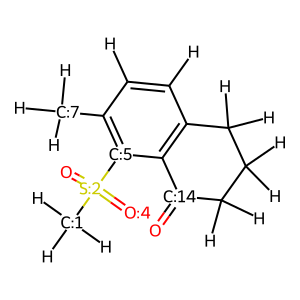

### SMILES: Cc1ccccc1Oc2c(C)cccc2C

Diaryl ether (6-6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 7-9 with atoms [7, 23, 1] and [9, 11, 16]

Summary of dihedrals for GIC scans:
 - scan 1: {'7_9': [[23, 7, 9, 11], [1, 7, 9, 16]]}
 - scan 2: {'7_9': [[23, 7, 9, 16], [1, 7, 9, 11]]}

Summary of identified substructures:
 - {'7_9': 'Diaryl ether (6-6)'}

Rotatable bond:


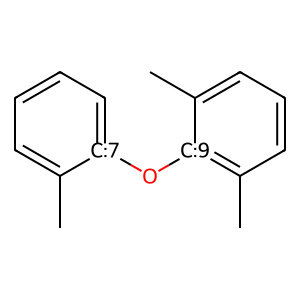

GIC atoms:


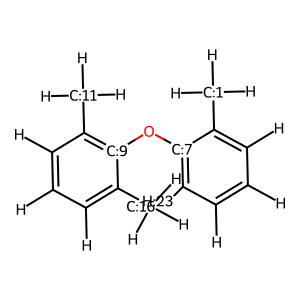

### SMILES: Cc1ccccc1Nc2c(C)cccc2C

Diaryl amine (6-6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 7-9 with atoms [7, 23, 1] and [9, 11, 16]

Summary of dihedrals for GIC scans:
 - scan 1: {'7_9': [[23, 7, 9, 11], [1, 7, 9, 16]]}
 - scan 2: {'7_9': [[23, 7, 9, 16], [1, 7, 9, 11]]}

Summary of identified substructures:
 - {'7_9': 'Diaryl amine (6-6)'}

Rotatable bond:


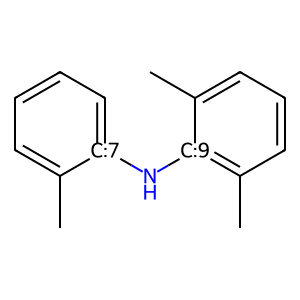

GIC atoms:


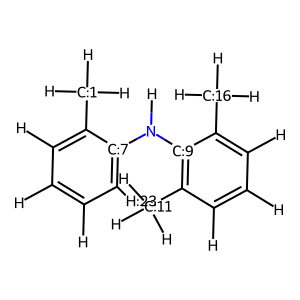

### SMILES: Cc1ccccc1Sc2c(C)cccc2C

Diaryl thioether (6-6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 7-9 with atoms [7, 23, 1] and [9, 11, 16]

Summary of dihedrals for GIC scans:
 - scan 1: {'7_9': [[23, 7, 9, 11], [1, 7, 9, 16]]}
 - scan 2: {'7_9': [[23, 7, 9, 16], [1, 7, 9, 11]]}

Summary of identified substructures:
 - {'7_9': 'Diaryl thioether (6-6)'}

Rotatable bond:


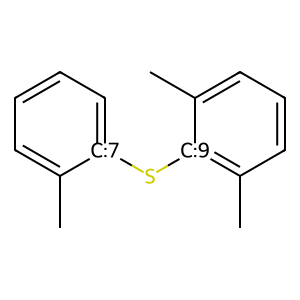

GIC atoms:


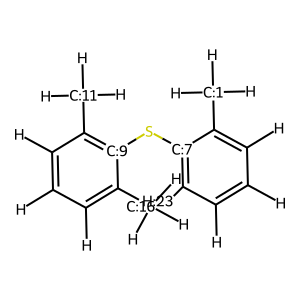

### SMILES: c1cc(cc(c1S(=O)c2ccc(cc2C)C)C)C

Diaryl thioether (6-6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 6-9 with atoms [6, 17, 19] and [9, 22, 15]
Sulfoxide (6) match identified:
 - too many hydrogens and/or lone pairs (>0): skipping the calculation
Sulfoxide (6) match identified:
 - too many hydrogens and/or lone pairs (>0): skipping the calculation

Summary of dihedrals for GIC scans:
 - scan 1: {'6_9': [[17, 6, 9, 22], [19, 6, 9, 15]]}
 - scan 2: {'6_9': [[17, 6, 9, 15], [19, 6, 9, 22]]}

Summary of identified substructures:
 - {'6_9': 'Diaryl thioether (6-6)'}

Rotatable bond:


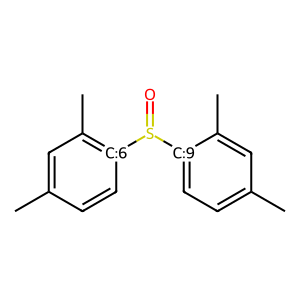

GIC atoms:


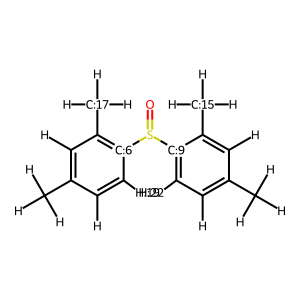

### SMILES: c1cc(cc(c1S(=O)(=O)c2ccc(cc2C)C)C)C

Diaryl thioether (6-6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 6-10 with atoms [6, 18, 20] and [10, 23, 16]
Sulfoxide (6) match identified:
 - too many hydrogens and/or lone pairs (>0): skipping the calculation
Sulfoxide (6) match identified:
 - too many hydrogens and/or lone pairs (>0): skipping the calculation
Sulfoxide (6) match identified:
 - too many hydrogens and/or lone pairs (>0): skipping the calculation
Sulfoxide (6) match identified:
 - too many hydrogens and/or lone pairs (>0): skipping the calculation
Sulfone (6) match identified:
 - too many hydrogens and/or lone pairs (>0): skipping the calculation
Sulfone (6) match identified:
 - too many hydrogens and/or lone pairs (>0): skipping the calculation

Summary of dihedrals for GIC scans:
 - scan 1: {'6_10': [[18, 6, 10, 23], [20, 6, 10, 16]]}
 - scan 2: {'6_10': [[18, 6, 10, 16], [20, 6, 10, 23]]}

Summary of identified substruc

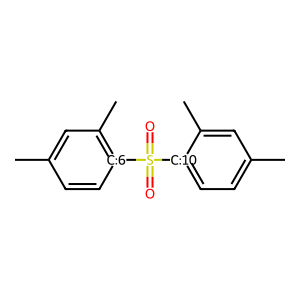

GIC atoms:


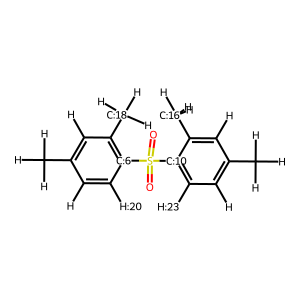

### SMILES: CC(C)(C)c1cc(N2CCCCC2)c(C(C)(C)C)cc1Cl

Aryl-aliphatic (6-6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 7-8 with atoms [7, 31, 15] and [8, 9, 13]

Summary of dihedrals for GIC scans:
 - scan 1: {'7_8': [[31, 7, 8, 9], [15, 7, 8, 13]]}
 - scan 2: {'7_8': [[31, 7, 8, 13], [15, 7, 8, 9]]}

Summary of identified substructures:
 - {'7_8': 'Aryl-aliphatic (6-6)'}

Rotatable bond:


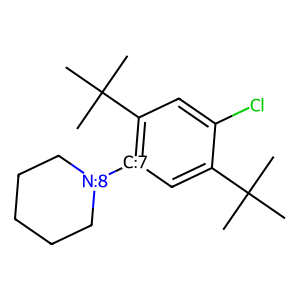

GIC atoms:


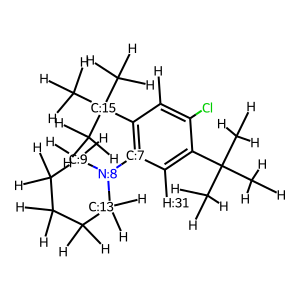

### SMILES: Oc1c(c(cc(c1)C)O)C2[C@@H](CCC(=C2)C)C(=C)C

Aryl-aliphatic (6-6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 3-10 with atoms [3, 1, 9] and [10, 11, 33]

Summary of dihedrals for GIC scans:
 - scan 1: {'3_10': [[1, 3, 10, 11], [9, 3, 10, 33]]}
 - scan 2: {'3_10': [[1, 3, 10, 33], [9, 3, 10, 11]]}

Summary of identified substructures:
 - {'3_10': 'Aryl-aliphatic (6-6)'}

Rotatable bond:


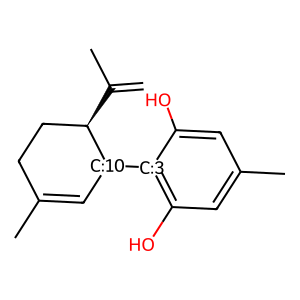

GIC atoms:


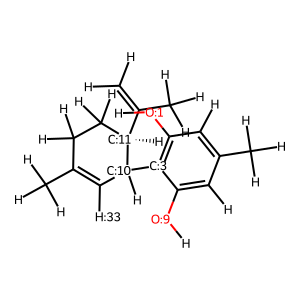

### SMILES: CC1CCC(C)C1c2c(C)cccc2C

Aryl-aliphatic (6-5) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 7-8 with atoms [7, 5, 2] and [8, 10, 15]

Summary of dihedrals for GIC scans:
 - scan 1: {'7_8': [[5, 7, 8, 10], [2, 7, 8, 15]]}
 - scan 2: {'7_8': [[5, 7, 8, 15], [2, 7, 8, 10]]}

Summary of identified substructures:
 - {'7_8': 'Aryl-aliphatic (6-5)'}

Rotatable bond:


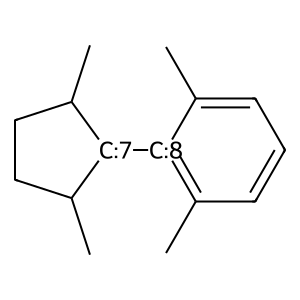

GIC atoms:


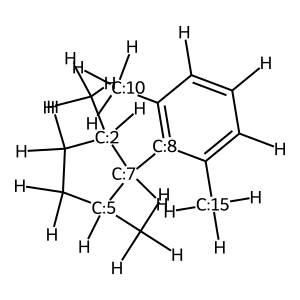

### SMILES: CC1CCCC(C)C1c2c(C)occ2C

Aryl-aliphatic (5-6) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 8-9 with atoms [8, 6, 2] and [9, 11, 15]

Summary of dihedrals for GIC scans:
 - scan 1: {'8_9': [[6, 8, 9, 11], [2, 8, 9, 15]]}
 - scan 2: {'8_9': [[6, 8, 9, 15], [2, 8, 9, 11]]}

Summary of identified substructures:
 - {'8_9': 'Aryl-aliphatic (5-6)'}

Rotatable bond:


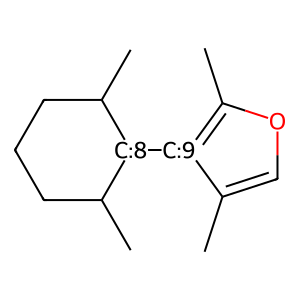

GIC atoms:


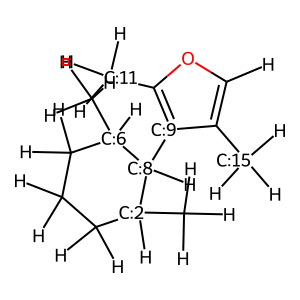

### SMILES: CC1CCC(C)C1c2c(C)occ2C

Aryl-aliphatic (5-5) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 7-8 with atoms [7, 5, 2] and [8, 10, 14]

Summary of dihedrals for GIC scans:
 - scan 1: {'7_8': [[5, 7, 8, 10], [2, 7, 8, 14]]}
 - scan 2: {'7_8': [[5, 7, 8, 14], [2, 7, 8, 10]]}

Summary of identified substructures:
 - {'7_8': 'Aryl-aliphatic (5-5)'}

Rotatable bond:


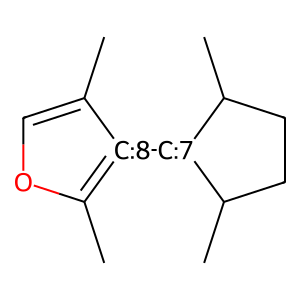

GIC atoms:


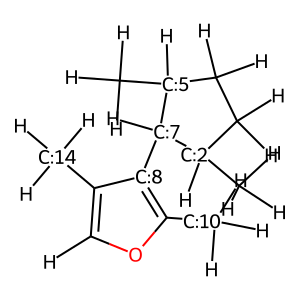

### SMILES: CC1=C(C(=CC1)C)C2=C(C)CC=C2C

Bialiphatic (5-5) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 3-8 with atoms [3, 1, 7] and [8, 10, 14]

Summary of dihedrals for GIC scans:
 - scan 1: {'3_8': [[1, 3, 8, 10], [7, 3, 8, 14]]}
 - scan 2: {'3_8': [[1, 3, 8, 14], [7, 3, 8, 10]]}

Summary of identified substructures:
 - {'3_8': 'Bialiphatic (5-5)'}

Rotatable bond:


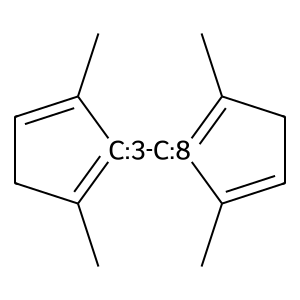

GIC atoms:


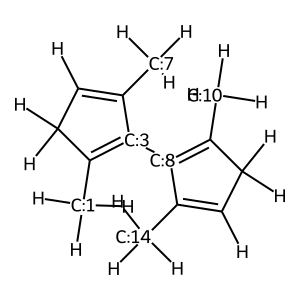

### SMILES: CC1=CC=C(C)C1C2C(=CC=C2C)C

Bialiphatic (5-5) match identified:
 - sufficient bulk for atropisomerism: initialize GIC scan around bond 7-8 with atoms [7, 6, 1] and [8, 14, 13]

Summary of dihedrals for GIC scans:
 - scan 1: {'7_8': [[6, 7, 8, 14], [1, 7, 8, 13]]}
 - scan 2: {'7_8': [[6, 7, 8, 13], [1, 7, 8, 14]]}

Summary of identified substructures:
 - {'7_8': 'Bialiphatic (5-5)'}

Rotatable bond:


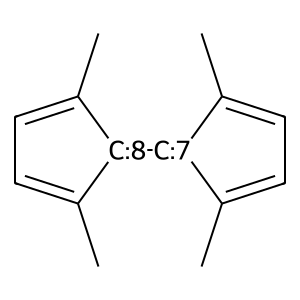

GIC atoms:


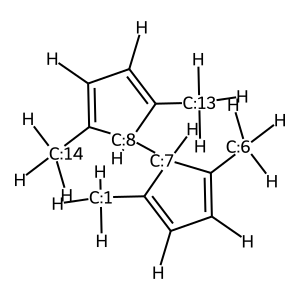

In [26]:
# Biaryls
parse('Cc1cccc(C)c1c2c(C)cccc2Cl') # 6,6
parse('Cc1occ(C)c1c2c(C)cccc2C') # 6,5
parse('Cc1occ(C)c1c2cocc2C') # 5,5
parse("CCOC(=O)c1c(C)[nH]c(c2ccccc2)c1c3c([nH]c(C)c3C(=O)OCC)c4ccccc4") # Literature 5,5
parse("CC(=O)N[C@H]1CCC2=CC(=C(C(=C2C3=CC=C(C(=O)C=C13)OC)OC)OC)OC") # Colchicine (7-membered)

# Benzamides and amides
parse('NC(=O)c1cccc2CCCC(=O)c12') # Benzamide
parse('NC(=S)c1cccc2CCCC(=O)c12') # Thiobenzamide
parse('CC(=O)Nc1cccc2CCCC(=O)c12') # Reversed benzamide
parse("CC1CCCC(=O)N1c2c(C)cccc2C") # Cyclic benzamide
parse("Cc1ccoc1C(=O)N") # 5-membered benzamide
parse("CC(=O)N") # Acetamide
parse("CN(C)C(C)=S") # Thioamide

# Sulfoxides
parse("CS(=O)c1c(C)ccc2CCCC(=O)c12") # 6-membered
parse("CS(=O)c1c(C)oc2CCCC(=O)c12") # 5-membered
parse("CS(=O)(=O)c1c(C)ccc2CCCC(=O)c12") # Sulfone

# Diaryls
parse("Cc1ccccc1Oc2c(C)cccc2C") # Ether
parse("Cc1ccccc1Nc2c(C)cccc2C") # Amine
parse("Cc1ccccc1Sc2c(C)cccc2C") # # Thioether
parse("c1cc(cc(c1S(=O)c2ccc(cc2C)C)C)C") # Sulfoxide
parse("c1cc(cc(c1S(=O)(=O)c2ccc(cc2C)C)C)C") # Sulfone

# Aryl-aliphatics
parse("CC(C)(C)c1cc(N2CCCCC2)c(C(C)(C)C)cc1Cl") # 6,6
parse("Oc1c(c(cc(c1)C)O)C2[C@@H](CCC(=C2)C)C(=C)C") # Cannabidiol (6,6)
parse("CC1CCC(C)C1c2c(C)cccc2C") # 6,5
parse("CC1CCCC(C)C1c2c(C)occ2C") # 5,6
parse("CC1CCC(C)C1c2c(C)occ2C") # 5,5

# Bialiphatics
parse("CC1=C(C(=CC1)C)C2=C(C)CC=C2C") # sp2 rotatable bond
parse("CC1=CC=C(C)C1C2C(=CC=C2C)C") # sp3 rotatable bond